In [72]:
# 🔋 Global EV Data Analysis — EDA Portfolio Project
#Name: vilas katpure
#Tools:Python, Pandas, NumPy, Matplotlib

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [74]:
df = pd.read_csv('/content/global ev.zip')
df

,region,category,parameter,mode,powertrain,year,unit,value
0,Australia,Historical,EV stock share,Cars,EV,2011,percent,0.00
1,Australia,Historical,EV sales share,Cars,EV,2011,percent,0.01
2,Australia,Historical,EV sales,Cars,BEV,2011,Vehicles,49.00
3,Australia,Historical,EV stock,Cars,BEV,2011,Vehicles,49.00
4,Australia,Historical,EV stock,Cars,BEV,2012,Vehicles,220.00
...,...,...,...,...,...,...,...,...
12649,World,Projection-STEPS,EV sales share,Cars,EV,2035,percent,55.00
12650,World,Projection-STEPS,EV stock share,Cars,EV,2035,percent,31.00
12651,World,Projection-APS,EV charging points,EV,Publicly available fast,2035,charging points,9400000.00
12652,World,Projection-APS,EV charging points,EV,Publicly available slow,2035,charging points,15000000.00


In [4]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)


In [5]:
print("Shape:",df.shape)
print("\nColumn Names:",df.columns.tolist())

Shape: (12654, 8)

Column Names: ['region', 'category', 'parameter', 'mode', 'powertrain', 'year', 'unit', 'value']


In [6]:
print("Data Types:")
print(df.dtypes)

print("Missing Values:")
print(df.isnull().sum())

Data Types:
region         object
category       object
parameter      object
mode           object
powertrain     object
year            int64
unit           object
value         float64
dtype: object
Missing Values:
region        0
category      0
parameter     0
mode          0
powertrain    0
year          0
unit          0
value         0
dtype: int64


In [7]:
for col in ['category', 'parameter', 'mode', 'powertrain']:
    print(f"{col}: {df[col].unique()}")
    print()

category: ['Historical' 'Projection-STEPS' 'Projection-APS']

parameter: ['EV stock share' 'EV sales share' 'EV sales' 'EV stock'
 'EV charging points' 'Electricity demand' 'Oil displacement Mbd'
 'Oil displacement, million lge']

mode: ['Cars' 'EV' 'Buses' 'Vans' 'Trucks']

powertrain: ['EV' 'BEV' 'PHEV' 'Publicly available fast' 'Publicly available slow'
 'FCEV']



In [8]:
print(df.describe())

          year        value
count 12654.00     12654.00
mean   2019.82    427374.17
std       5.48   6860498.32
min    2010.00         0.00
25%    2016.00         2.00
50%    2020.00       130.00
75%    2022.00      5500.00
max    2035.00 440000000.00


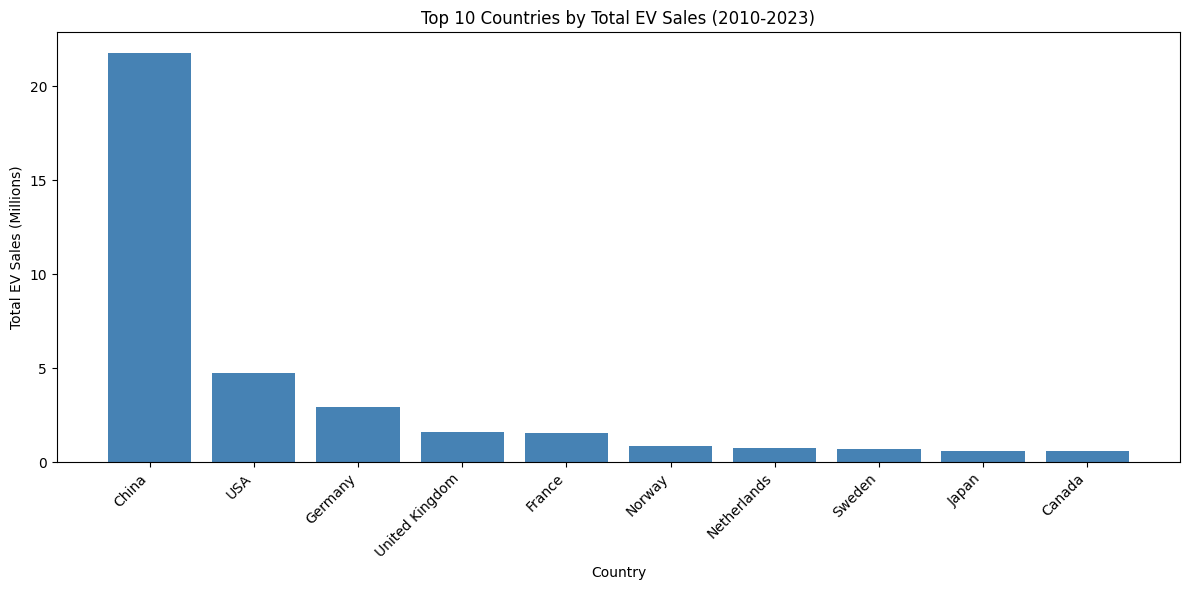

In [9]:
#Top 10 Countries by EV Sales (Bar Chart)

# Step 1 - Filter the data
ev_sales = df[
    (df['parameter'] == 'EV sales') &
    (df['category'] == 'Historical') &
    (df['mode'] == 'Cars') &
    (df['powertrain'].isin(['BEV', 'PHEV'])) &
    (~df['region'].isin(['World', 'Europe', 'EU27', 'Rest of the world']))
]

# Step 2 - Group and sort
top10 = ev_sales.groupby('region')['value'].sum().sort_values(ascending=False).head(10)

# Step 3 - Plotting the graph
plt.figure(figsize=(12, 6))
plt.bar(top10.index, top10.values / 1e6, color='steelblue')
plt.title('Top 10 Countries by Total EV Sales (2010-2023)')
plt.xlabel('Country')
plt.ylabel('Total EV Sales (Millions)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

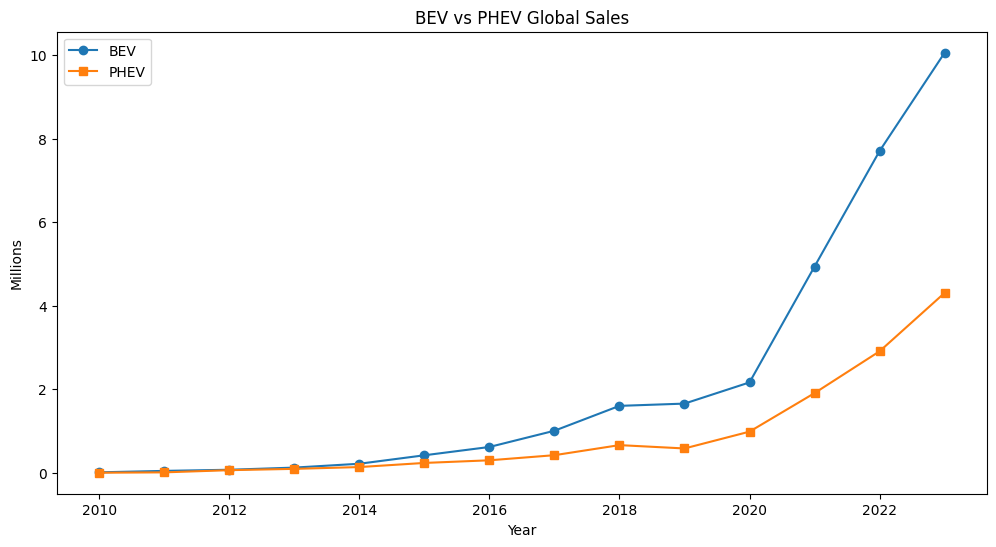

In [10]:
#Global EV Sales Growth Over Time (Line Chart)

global_sales = df[
    (df['parameter'] == 'EV sales') &
    (df['category'] == 'Historical') &
    (df['region'] == 'World') &
    (df['powertrain'].isin(['BEV', 'PHEV']))
]

pivot = global_sales.groupby(['year', 'powertrain'])['value'].sum().unstack()

plt.figure(figsize=(12, 6))
plt.plot(pivot.index, pivot['BEV'] / 1e6, marker='o', label='BEV')
plt.plot(pivot.index, pivot['PHEV'] / 1e6, marker='s', label='PHEV')
plt.title('BEV vs PHEV Global Sales')
plt.xlabel('Year')
plt.ylabel('Millions')
plt.legend()
plt.show()

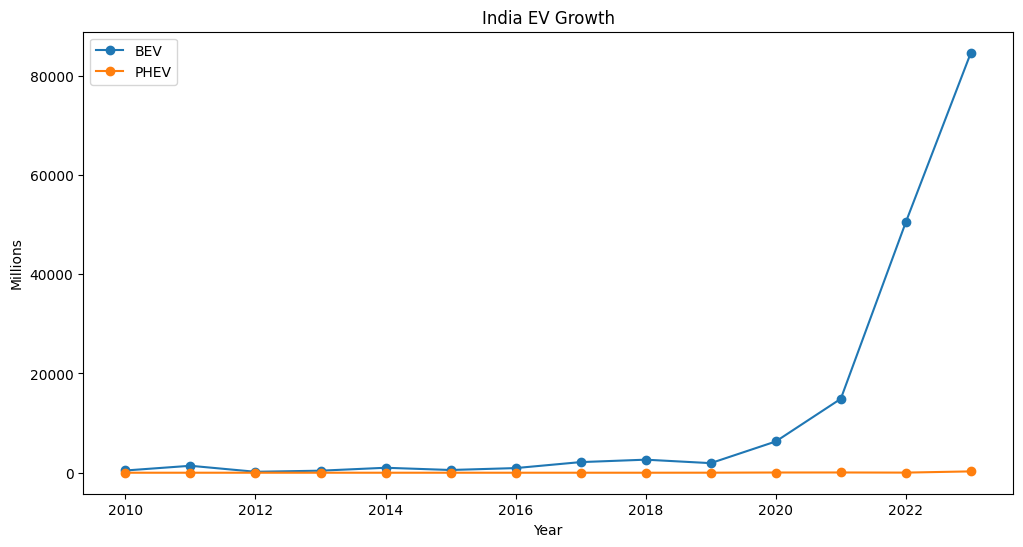

In [11]:
#India's EV Growth
india= df[
   (df['parameter'] == 'EV sales')&
   (df['region'] == 'India') &
   (df['category'] == 'Historical') &
   (df['powertrain'].isin(['BEV', 'PHEV']))
]
india_sales = india.groupby(['year','powertrain'])['value'].sum().unstack().fillna(0)

plt.figure(figsize=(12,6))
for col in india_sales.columns:
    plt.plot(india_sales.index, india_sales[col], marker='o', label=col)

plt.title('India EV Growth')
plt.xlabel('Year')
plt.ylabel('Millions')
plt.legend()
plt.show()

In [12]:
#correlation

df_corr = df.copy()
cat_cols = ['region', 'category', 'parameter', 'mode', 'powertrain', 'unit']
for col in cat_cols:
    df_corr[col] = df_corr[col].astype('category').cat.codes
print(df_corr.head())
corr_matrix = df_corr.corr()
print(corr_matrix)

   region  category  parameter  mode  powertrain  year  unit  value
0       0         0          4     1           1  2011     5   0.00
1       0         0          2     1           1  2011     5   0.01
2       0         0          1     1           0  2011     3  49.00
3       0         0          3     1           0  2011     3  49.00
4       0         0          3     1           0  2012     3 220.00
            region  category  parameter  mode  powertrain  year  unit  value
region        1.00      0.09       0.04 -0.03        0.00  0.07 -0.05   0.03
category      0.09      1.00       0.16  0.06        0.01  0.60 -0.19   0.08
parameter     0.04      0.16       1.00  0.01       -0.33  0.07 -0.38  -0.00
mode         -0.03      0.06       0.01  1.00        0.00  0.05 -0.00  -0.02
powertrain    0.00      0.01      -0.33  0.00        1.00  0.05  0.07  -0.03
year          0.07      0.60       0.07  0.05        0.05  1.00 -0.13   0.12
unit         -0.05     -0.19      -0.38 -0.00        

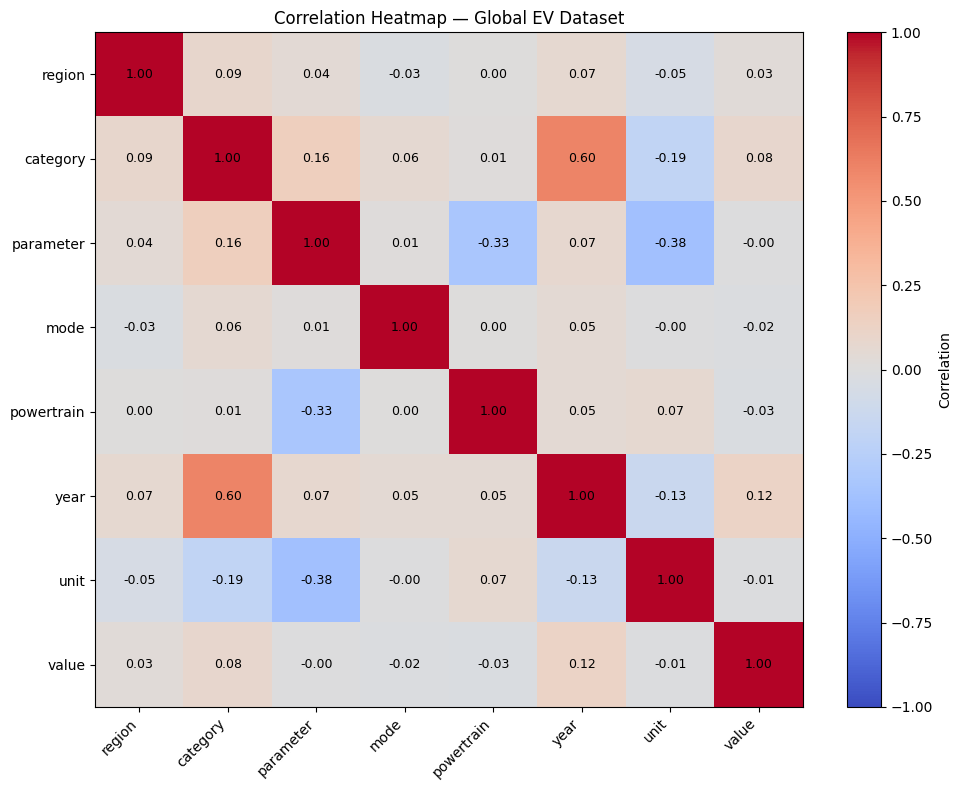

In [13]:
#Correlation Heatmap

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)

plt.colorbar(label='Correlation')

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                 ha='center', va='center', fontsize=9)

plt.title('Correlation Heatmap — Global EV Dataset')
plt.tight_layout()
plt.show()

Highest sales year: 2023
Total sales that year: 14385660.0


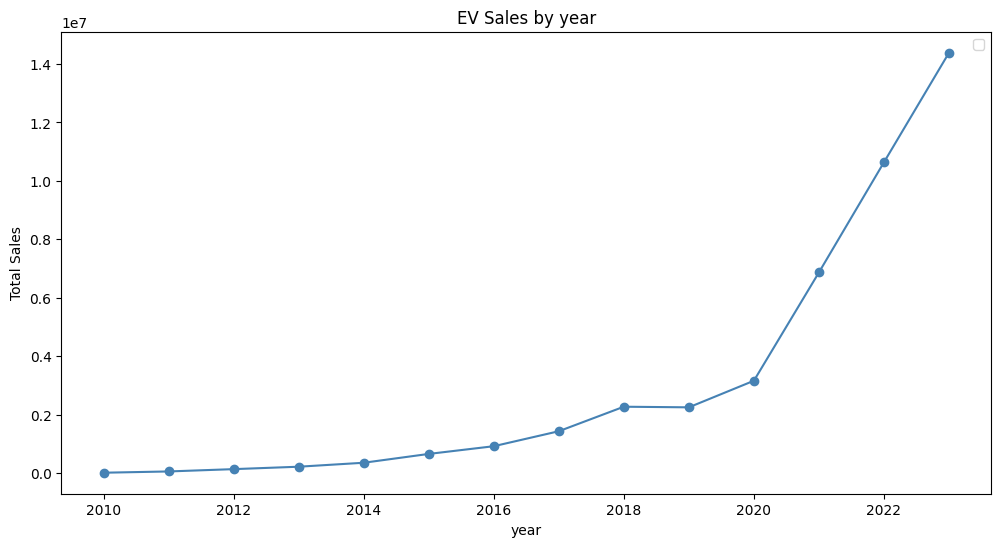

In [25]:
# Which year had the highest EV sales globally?
sales= df[
    (df['parameter']=='EV sales')&
    (df['region']=='World')&
    (df['category'] == 'Historical')
]
sales_by_year = sales.groupby('year')['value'].sum()

print("Highest sales year:", sales_by_year.idxmax())
print("Total sales that year:", sales_by_year.max())

plt.figure(figsize=(12,6))
plt.plot(sales_by_year.index,sales_by_year.values,marker='o',color='steelblue')
plt.title('EV Sales by year')
plt.xlabel('year')
plt.ylabel('Total Sales')
plt.legend()
plt.show()

In [33]:
#How many total EVs does India have on road till 2023?

india_ev = df[
    (df['region']=='india')&
    (df['parameter']=='EV stock')&
    (df['category']=='Historical')
]

total = india_ev['value'].sum()
print("Total EVs on Road in India till 2023:",total)

Total EVs on Road in India till 2023: 0.0


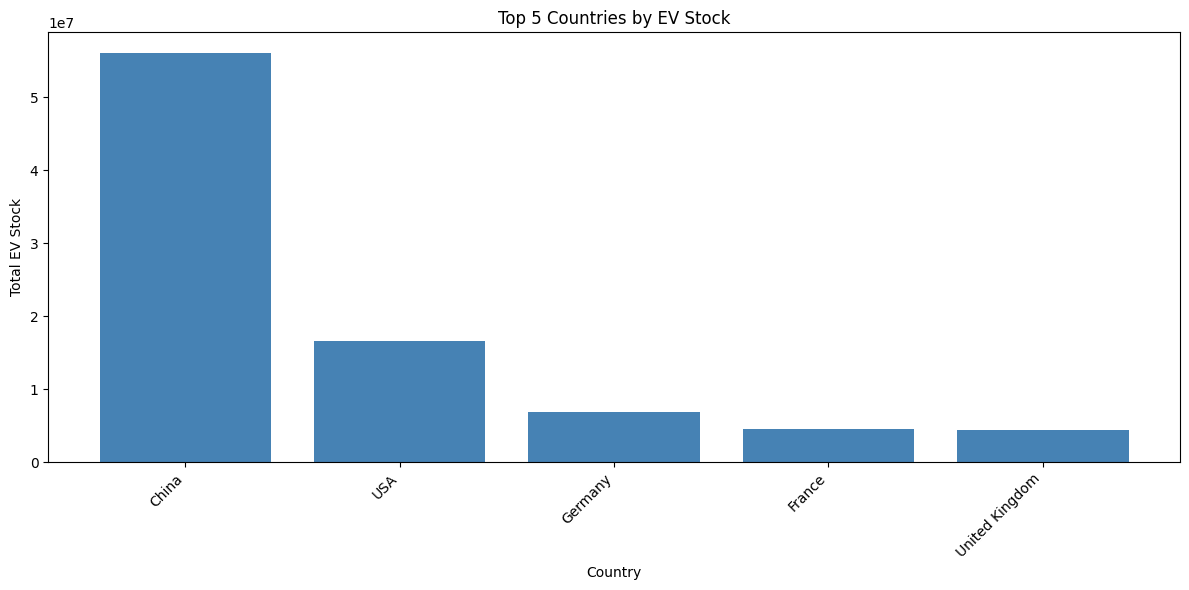

In [40]:
#Top 5 countries by EV stock
ev_stock =df[
    (df['parameter'] == 'EV stock') &
    (df['category'] == 'Historical') &
    (df['mode'] == 'Cars') &
    (df['powertrain'].isin(['BEV', 'PHEV'])) &
    (~df['region'].isin(['World', 'Europe', 'EU27', 'Rest of the world']))
 ]
top5 = ev_stock.groupby('region')['value'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(12,6))
plt.bar(top5.index, top5.values, color='steelblue')
plt.title('Top 5 Countries by EV Stock')
plt.xlabel('Country')
plt.ylabel('Total EV Stock')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Total sales by powertrain powertrain
BEV    30635440.00
FCEV      89667.00
PHEV   12606572.00
Name: value, dtype: float64


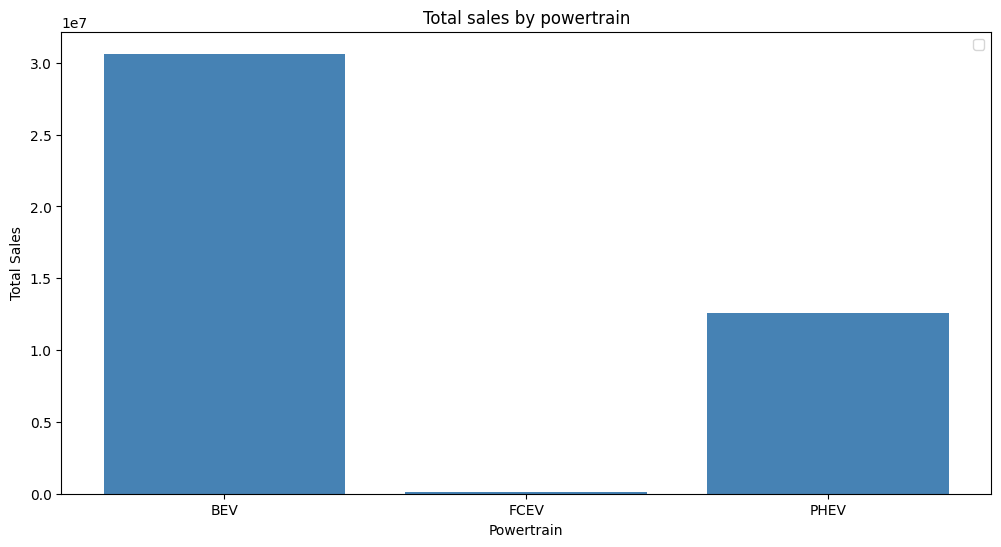

In [64]:
# Which powertrain (BEV or PHEV) has more total sales worldwide
powertrain =df[
    (df['parameter']=='EV sales')&
    (df['category']=='Historical')&
    (df['region']=='World')
    ]

total = powertrain.groupby('powertrain')['value'].sum()

print("Total sales by powertrain",total)
plt.figure(figsize=(12,6))
plt.bar(total.index,total.values,color='steelblue')
plt.title('Total sales by powertrain')
plt.xlabel('Powertrain')
plt.ylabel('Total Sales')
plt.legend()
plt.show()

region    China   India
year                   
2010    2530.00  450.00
2011    5870.00 1400.00
2012   12440.00  190.00
2013   20280.00  410.00
2014   83480.00 1000.00


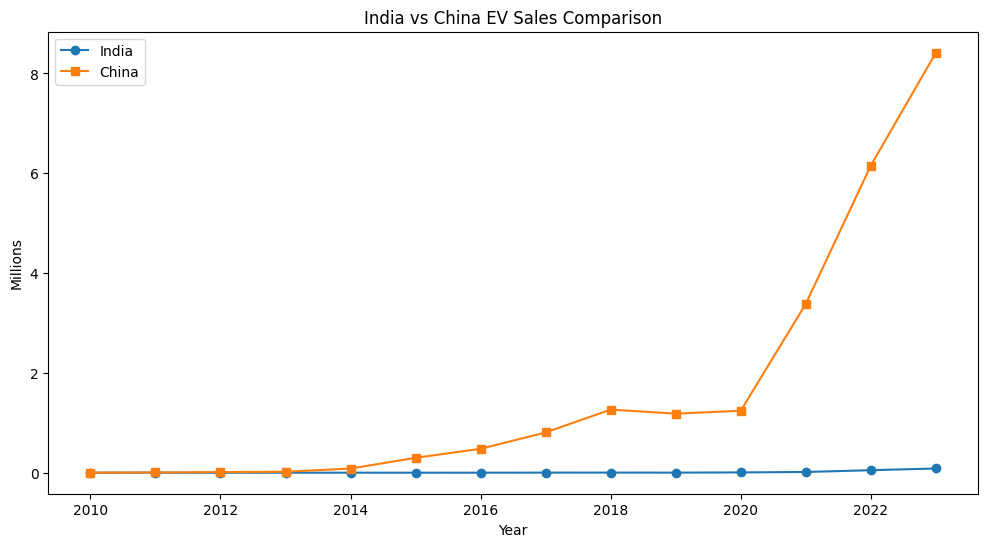

In [67]:
# Plot India vs China EV sales comparison over years


EV_sales = df[
    (df['parameter'] == 'EV sales') &
    (df['category'] == 'Historical') &
    (df['region'].isin(['India', 'China']))
]


comparison = EV_sales.groupby(['year', 'region'])['value'].sum().unstack()

print(comparison.head())


plt.figure(figsize=(12, 6))
plt.plot(comparison.index, comparison['India'] / 1e6, marker='o', label='India')
plt.plot(comparison.index, comparison['China'] / 1e6, marker='s', label='China')
plt.title('India vs China EV Sales Comparison')
plt.xlabel('Year')
plt.ylabel('Millions')
plt.legend()
plt.show()

In [63]:
## Conclusion
# 1. China leads global EV market by huge margin
# 2. BEV is clearly winning over PHEV
# 3. India is small but growing fast post 2020
# 4. Future projections show 300M+ EVs by 2035